# Credit Card Fraud Detection: Data Loading

Dataset: [mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

The file `creditcard.csv` has 284,807 transactions, with `Time`, `Amount`, anonymized PCA features `V1`-`V28`, and the label `Class` (1 = fraud, 0 = genuine). Fraud is about 0.17% of rows, so the classes are heavily imbalanced.

## 1. Install dependencies

In [1]:
#%pip install -q kagglehub pandas scikit-learn matplotlib

## 2. Download from Kaggle

`kagglehub` pulls the dataset by its slug and caches it locally. For a public dataset like this one it often works with no credentials. If it asks for auth, use one of these:

- Set env vars `KAGGLE_USERNAME` and `KAGGLE_KEY` (create a token at kaggle.com → Settings → API)
- Or put `kaggle.json` in `~/.kaggle/`
- In Colab, add them as Secrets or upload `kaggle.json`

In [2]:
import os
import kagglehub

# Uncomment if you need to authenticate with env vars:
# os.environ["KAGGLE_USERNAME"] = "your_username"
# os.environ["KAGGLE_KEY"] = "your_api_key"

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset files at:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset files at: /kaggle/input/creditcardfraud
['creditcard.csv']


### Alternative: official Kaggle CLI

Use this instead of the cell above if you prefer it (requires credentials as above).

In [3]:
# !pip install -q kaggle
# !kaggle datasets download -d mlg-ulb/creditcardfraud -p data --unzip
# path = "data"

## 3. Load into pandas

In [4]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "creditcard.csv"))
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Quick sanity checks

In [5]:
print(df.isna().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicate rows")
df.describe().T.head(8)

0 missing values
1081 duplicate rows


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494


Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%


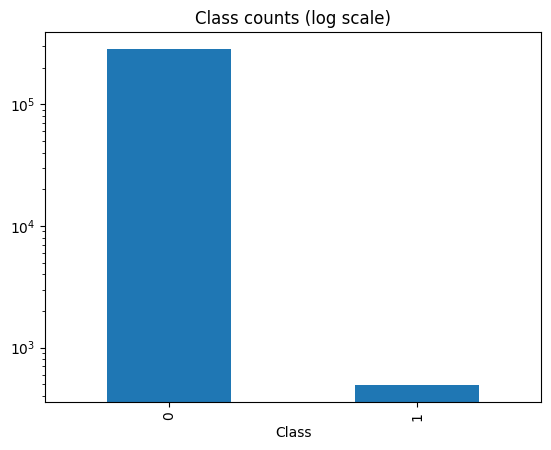

In [6]:
counts = df["Class"].value_counts()
print(counts)
print(f"Fraud rate: {df['Class'].mean():.4%}")
counts.plot(kind="bar", logy=True, title="Class counts (log scale)");

## 5. Train/test split

Use a stratified split so the test set keeps the same tiny fraud fraction. Split before any scaling or resampling to avoid leakage. Also, accuracy is useless here (predicting all-genuine gets ~99.83%); evaluate with precision/recall, PR-AUC, or F1.

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Class")
y = df["Class"]

# 1) Hold out the test set first
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) Split the rest into train / val (0.25 of 80% = 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)
print(
    "Fraud rate | train:", y_train.mean(),
    "| val:", y_val.mean(),
    "| test:", y_test.mean(),
)

(170883, 30) (56962, 30) (56962, 30)
Fraud rate | train: 0.0017263273701889597 | val: 0.0017380007724447878 | test: 0.0017204452090867595


## 6. Baseline model (starting point)

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    precision_recall_curve,
)
import numpy as np

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=1000),
)
clf.fit(X_train, y_train)

# --- Validation: check performance and pick a threshold ---
val_proba = clf.predict_proba(X_val)[:, 1]
print("Val PR-AUC:", average_precision_score(y_val, val_proba))

prec, rec, thr = precision_recall_curve(y_val, val_proba)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = thr[np.argmax(f1)]
print(f"Best val threshold (max F1): {best_thr:.4f}  |  Val F1: {f1.max():.4f}")

# --- Test: evaluate once, using the threshold chosen on val ---
test_proba = clf.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

print("\nTest PR-AUC:", average_precision_score(y_test, test_proba))
print(classification_report(y_test, test_pred, digits=4))

Val PR-AUC: 0.6807113141715643
Best val threshold (max F1): 1.0000  |  Val F1: 0.7676

Test PR-AUC: 0.7178737904575203
              precision    recall  f1-score   support

           0     0.9997    0.9996    0.9997     56864
           1     0.8000    0.8163    0.8081        98

    accuracy                         0.9993     56962
   macro avg     0.8998    0.9080    0.9039     56962
weighted avg     0.9993    0.9993    0.9993     56962



In [9]:
# pip install xgboost
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    precision_recall_curve,
)

# Class imbalance weight: (# genuine) / (# fraud) in the training set
spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=2000,            # upper bound; early stopping picks the real number
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="aucpr",          # PR-AUC suits the heavy imbalance
    early_stopping_rounds=50,     # stops when val aucpr hasn't improved for 50 rounds
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)
print("Best iteration:", xgb_clf.best_iteration)

# --- Validation: check performance and pick a threshold ---
val_proba = xgb_clf.predict_proba(X_val)[:, 1]
print("Val PR-AUC:", average_precision_score(y_val, val_proba))

prec, rec, thr = precision_recall_curve(y_val, val_proba)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = thr[np.argmax(f1)]
print(f"Best val threshold (max F1): {best_thr:.4f}  |  Val F1: {f1.max():.4f}")

# --- Test: evaluate once, using the threshold chosen on val ---
test_proba = xgb_clf.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

print("\nTest PR-AUC:", average_precision_score(y_test, test_proba))
print(classification_report(y_test, test_pred, digits=4))

[0]	validation_0-aucpr:0.53278
[50]	validation_0-aucpr:0.70522
[100]	validation_0-aucpr:0.75418
[150]	validation_0-aucpr:0.77836
[200]	validation_0-aucpr:0.80978
[250]	validation_0-aucpr:0.82169
[300]	validation_0-aucpr:0.82522
[350]	validation_0-aucpr:0.82837
[400]	validation_0-aucpr:0.83085
[450]	validation_0-aucpr:0.83095
[460]	validation_0-aucpr:0.83148
Best iteration: 410
Val PR-AUC: 0.8316779219746712
Best val threshold (max F1): 0.8478  |  Val F1: 0.8556

Test PR-AUC: 0.8759398278594234
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9302    0.8163    0.8696        98

    accuracy                         0.9996     56962
   macro avg     0.9650    0.9081    0.9347     56962
weighted avg     0.9996    0.9996    0.9996     56962



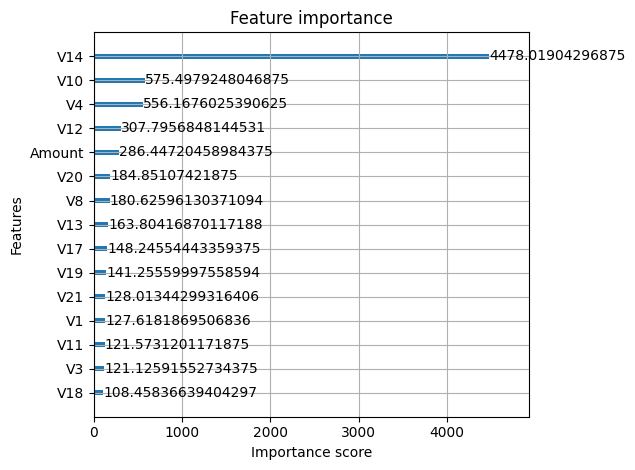

In [10]:
import matplotlib.pyplot as plt

xgb.plot_importance(xgb_clf, max_num_features=15, importance_type="gain")
plt.tight_layout()
plt.show()

In [17]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tabm import TabM
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_curve,
)

torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", device)

# ---------- Preprocessing (fit on train only) ----------
def prep(X):
    X = X.copy()
    X["Time"] = X["Time"] % 86400            # seconds since start -> time of day
    return X

# Quantile transform is the recommended numerical preprocessing for TabM-style models
qt = QuantileTransformer(n_quantiles=1000, output_distribution="normal", random_state=42)
qt.fit(prep(X_train))
to_t = lambda X: torch.tensor(qt.transform(prep(X)), dtype=torch.float32)

Xtr_t, Xva_t, Xte_t = to_t(X_train), to_t(X_val), to_t(X_test)
ytr_t = torch.tensor(y_train.values, dtype=torch.float32)
train_dl = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=1024, shuffle=True)

# ---------- Model ----------
K = 32  # number of implicit ensemble members
model = TabM.make(
    n_num_features=Xtr_t.shape[1],
    cat_cardinalities=None,      # no categorical features in this dataset
    d_out=1,                     # binary classification -> one logit
    k=K,
    n_blocks=4,
    d_block=256,
    dropout=0.1,
).to(device)

pos_weight = torch.tensor(np.sqrt((y_train == 0).sum() / (y_train == 1).sum()),
                          dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

def forward_logits(xb):
    # TabM output: (batch, k, d_out) -> (batch, k)
    return model(xb, None).squeeze(-1)

@torch.no_grad()
def predict_proba(X_t, bs=8192):
    model.eval()
    out = []
    for i in range(0, len(X_t), bs):
        logits = forward_logits(X_t[i:i + bs].to(device))
        out.append(torch.sigmoid(logits).mean(dim=1).cpu())   # average over the k members
    return torch.cat(out).numpy()

# ---------- Training with early stopping on val PR-AUC ----------
max_epochs, patience = 200, 15
best_ap, best_state, bad_epochs = -1, None, 0

for epoch in range(1, max_epochs + 1):
    model.train()
    total = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = forward_logits(xb)                       # (B, k)
        # Every member is trained independently on the same target
        loss = criterion(logits, yb[:, None].expand_as(logits))
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)

    val_ap = average_precision_score(y_val, predict_proba(Xva_t))
    scheduler.step(val_ap)

    if val_ap > best_ap:
        best_ap, best_state, bad_epochs = val_ap, copy.deepcopy(model.state_dict()), 0
    else:
        bad_epochs += 1

    if epoch % 5 == 0 or bad_epochs == 0:
        print(f"Epoch {epoch:3d} | train loss {total/len(Xtr_t):.4f} | val PR-AUC {val_ap:.4f}"
              f"{'  *' if bad_epochs == 0 else ''}")
    if bad_epochs >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
print(f"\nBest val PR-AUC: {best_ap:.4f}")

# ---------- Threshold on val, evaluate once on test ----------
val_proba = predict_proba(Xva_t)
prec, rec, thr = precision_recall_curve(y_val, val_proba)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = thr[np.argmax(f1)]
print(f"Best val threshold (max F1): {best_thr:.4f}  |  Val F1: {f1.max():.4f}")

test_proba = predict_proba(Xte_t)
test_pred = (test_proba >= best_thr).astype(int)
print("\nTest PR-AUC:", average_precision_score(y_test, test_proba))
print(classification_report(y_test, test_pred, digits=4))

Device: cuda
Epoch   1 | train loss 0.1010 | val PR-AUC 0.6953  *
Epoch   2 | train loss 0.0381 | val PR-AUC 0.7044  *
Epoch   5 | train loss 0.0287 | val PR-AUC 0.7143  *
Epoch   7 | train loss 0.0249 | val PR-AUC 0.7398  *
Epoch  10 | train loss 0.0211 | val PR-AUC 0.7410  *
Epoch  11 | train loss 0.0196 | val PR-AUC 0.7441  *
Epoch  12 | train loss 0.0186 | val PR-AUC 0.7532  *
Epoch  13 | train loss 0.0166 | val PR-AUC 0.7598  *
Epoch  15 | train loss 0.0159 | val PR-AUC 0.7622  *
Epoch  17 | train loss 0.0138 | val PR-AUC 0.7819  *
Epoch  20 | train loss 0.0125 | val PR-AUC 0.7755
Epoch  21 | train loss 0.0122 | val PR-AUC 0.7850  *
Epoch  23 | train loss 0.0112 | val PR-AUC 0.7879  *
Epoch  25 | train loss 0.0099 | val PR-AUC 0.7877
Epoch  29 | train loss 0.0069 | val PR-AUC 0.8001  *
Epoch  30 | train loss 0.0063 | val PR-AUC 0.7978
Epoch  31 | train loss 0.0062 | val PR-AUC 0.8029  *
Epoch  35 | train loss 0.0056 | val PR-AUC 0.7973
Epoch  37 | train loss 0.0045 | val PR-AUC 0.